# Visão Clássica v2 — Detecção de Anomalias em Painéis Solares

Classificação de anomalias em painéis solares por visão computacional clássica
(sem deep learning). O pipeline:

1. **Pré-processamento e visualização** das imagens infravermelhas (24x40 px).
2. **Extração de features** por imagem: intensidade, forma da região quente
   (limiar Otsu), bordas (Canny), textura (gradiente Sobel), simetria e histograma.
3. **Classificação** com RandomForest treinado sobre essas features, comparado
   a uma regra manual como baseline.
4. **Avaliação** por classe (precision/recall/F1), matriz de confusão e importância
   das features.

Tudo roda em CPU (não precisa de GPU). Imagens aparecem inline a cada etapa.

## 1. Setup e download do dataset

Baixa e extrai em Python puro (funciona no Colab sem `!wget`/`!unzip`). Pula se já existe.

In [239]:
import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tqdm import tqdm

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:  # notebook (Jupyter/Colab): __file__ nao existe
    BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "InfraredSolarModules"
DATASET_URL = "https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip"


def garantir_dataset():
    if (DATA_DIR / "module_metadata.json").exists():
        print(f"Dataset ja presente em {DATA_DIR}")
        return
    zip_path = BASE_DIR / "2020-02-14_InfraredSolarModules.zip"
    if not zip_path.exists():
        print(f"Baixando dataset de {DATASET_URL} ...")
        urllib.request.urlretrieve(DATASET_URL, zip_path)
    print("Extraindo dataset ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BASE_DIR)
    print(f"Dataset pronto em {DATA_DIR}")


garantir_dataset()

Dataset ja presente em /home/yurimn/Documentos/visao_computacional/solar-panel-anomaly-detection/InfraredSolarModules


## 2. Leitura do JSON e criação do DataFrame

In [240]:
with open(DATA_DIR / "module_metadata.json", "r") as f:
    metadados = json.load(f)

df = pd.DataFrame.from_dict(metadados, orient="index")
print(df.head())
print("\n--- CONTAGEM DE CLASSES ---")
print(df["anomaly_class"].value_counts())

         image_filepath anomaly_class
13357  images/13357.jpg    No-Anomaly
13356  images/13356.jpg    No-Anomaly
19719  images/19719.jpg    No-Anomaly
11542  images/11542.jpg    No-Anomaly
11543  images/11543.jpg    No-Anomaly

--- CONTAGEM DE CLASSES ---
anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
Name: count, dtype: int64


## 3. Visualização das amostras por classe

Imagens infravermelhas em tons de cinza (24x40 px). Defeitos térmicos aparecem
como regiões mais claras (quentes); outras anomalias (sombra, vegetação) como regiões escuras.

In [241]:
def visualizar_amostras(df, classe_nome, num_amostras=5):
    df_filtrado = df[df["anomaly_class"] == classe_nome]
    amostras = df_filtrado.sample(min(len(df_filtrado), num_amostras))
    fig, axes = plt.subplots(1, num_amostras, figsize=(15, 3))
    fig.suptitle(f"Amostras da classe: {classe_nome}", fontsize=16)
    if num_amostras == 1:
        axes = [axes]
    for ax, caminho_imagem in zip(axes, amostras["image_filepath"]):
        img = cv2.imread(str(DATA_DIR / caminho_imagem), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

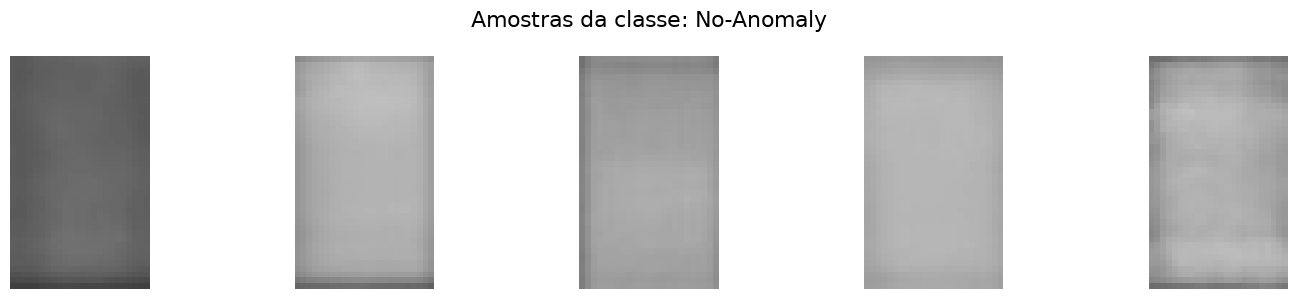

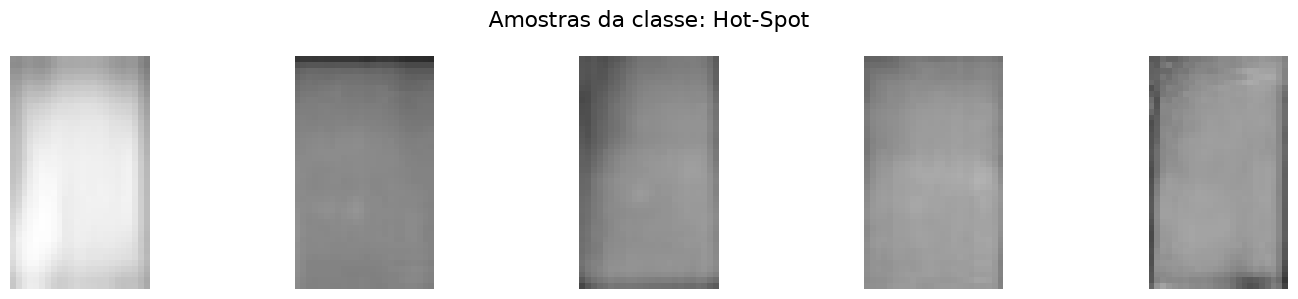

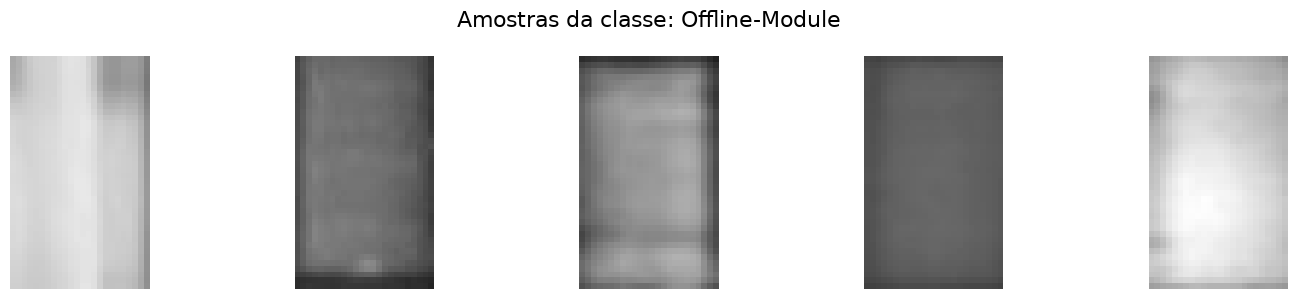

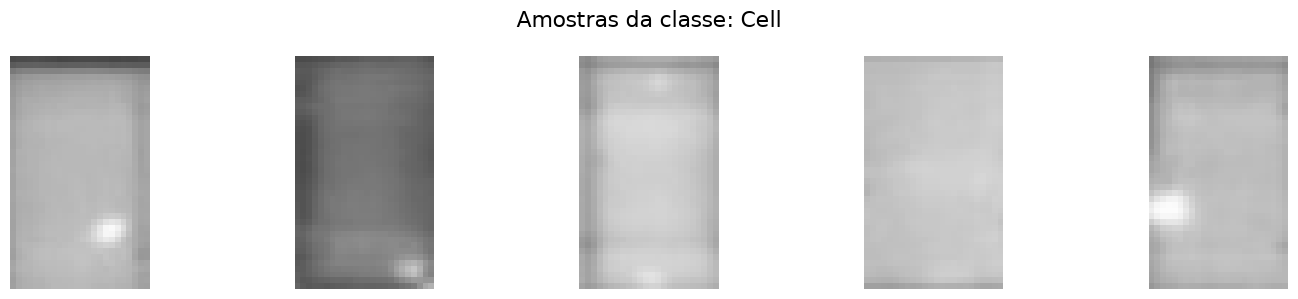

In [242]:
for classe in ["No-Anomaly", "Hot-Spot", "Offline-Module", "Cell"]:
    visualizar_amostras(df, classe, num_amostras=5)

## 4. Pipeline clássico: threshold → morfologia → contornos

Demonstração numa imagem `Cell` (ponto quente): binariza, limpa com morfologia,
extrai contornos e desenha a caixa do defeito.

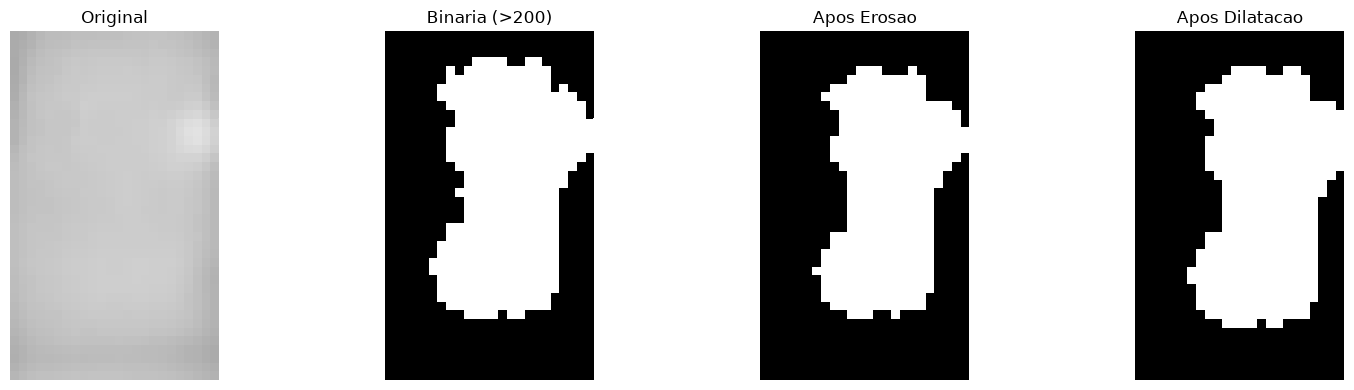

In [243]:
amostra = df[df["anomaly_class"] == "Cell"].sample(1).iloc[0]
img_original = cv2.imread(str(DATA_DIR / amostra["image_filepath"]), cv2.IMREAD_GRAYSCALE)

limiar = 200
_, img_binaria = cv2.threshold(img_original, limiar, 255, cv2.THRESH_BINARY)
kernel = np.ones((2, 2), np.uint8)
img_erodida = cv2.erode(img_binaria, kernel, iterations=1)
img_dilatada = cv2.dilate(img_erodida, kernel, iterations=1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, titulo in zip(
    axes,
    [img_original, img_binaria, img_erodida, img_dilatada],
    ["Original", f"Binaria (>{limiar})", "Apos Erosao", "Apos Dilatacao"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Extração de features

Aqui extraímos **~25 features** por imagem,
cobrindo vários tipos de anomalia (não só ponto quente):

- **Intensidade**: média, desvio, máx, mín, percentil 90
- **Região quente** (limiar Otsu adaptativo): fração, nº de blobs, área/extensão/aspecto do maior, cobertura por linha/coluna
- **Região escura**: fração de pixels frios → sombra / vegetação
- **Bordas** (Canny): densidade → trincas (Cracking)
- **Textura** (gradiente Sobel): rugosidade → sujeira (Soiling)
- **Simetria** esquerda-direita / cima-baixo
- **Histograma** (8 bins): distribuição térmica

In [244]:
def extrair_features(img):
    img = img.astype(np.uint8)
    total = img.size
    f = {}

    # Intensidade
    f["mean_int"] = float(img.mean())
    f["std_int"] = float(img.std())
    f["max_int"] = float(img.max())
    f["min_int"] = float(img.min())
    f["p90_int"] = float(np.percentile(img, 90))

    # Regiao quente via Otsu (adaptativo) com piso absoluto
    otsu_t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t = max(otsu_t, 180)
    _, hot = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    hot = cv2.morphologyEx(hot, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    f["hot_fraction"] = float(hot.sum() / 255) / total

    contornos, _ = cv2.findContours(hot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = [c for c in contornos if cv2.contourArea(c) >= 2]
    f["num_blobs"] = float(len(blobs))
    if blobs:
        maior = max(blobs, key=cv2.contourArea)
        area = cv2.contourArea(maior)
        x, y, w, h = cv2.boundingRect(maior)
        f["largest_area"] = float(area)
        f["largest_extent"] = float(area / (w * h)) if w * h > 0 else 0.0
        f["largest_aspect"] = float(w / h) if h > 0 else 0.0
    else:
        f["largest_area"] = f["largest_extent"] = f["largest_aspect"] = 0.0
    f["row_cov"] = float((hot.sum(axis=1) > 0).mean())
    f["col_cov"] = float((hot.sum(axis=0) > 0).mean())

    # Regiao escura (sombra / vegetacao): pixels bem abaixo da media
    f["dark_fraction"] = float((img < (img.mean() - img.std())).mean())

    # Bordas (trincas) e textura (sujeira)
    f["edge_density"] = float((cv2.Canny(img, 50, 150) > 0).mean())
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    f["grad_mean"] = float(np.sqrt(gx ** 2 + gy ** 2).mean())

    # Simetria
    imgf = img.astype(np.float32)
    f["sym_lr"] = float(np.abs(imgf - np.fliplr(imgf)).mean())
    f["sym_tb"] = float(np.abs(imgf - np.flipud(imgf)).mean())

    # Histograma (8 bins, normalizado)
    hist = cv2.calcHist([img], [0], None, [8], [0, 256]).flatten()
    hist = hist / hist.sum()
    for i, hv in enumerate(hist):
        f[f"hist{i}"] = float(hv)

    return f


FEAT_NAMES = list(extrair_features(img_original).keys())
print(f"{len(FEAT_NAMES)} features:", FEAT_NAMES)

25 features: ['mean_int', 'std_int', 'max_int', 'min_int', 'p90_int', 'hot_fraction', 'num_blobs', 'largest_area', 'largest_extent', 'largest_aspect', 'row_cov', 'col_cov', 'dark_fraction', 'edge_density', 'grad_mean', 'sym_lr', 'sym_tb', 'hist0', 'hist1', 'hist2', 'hist3', 'hist4', 'hist5', 'hist6', 'hist7']


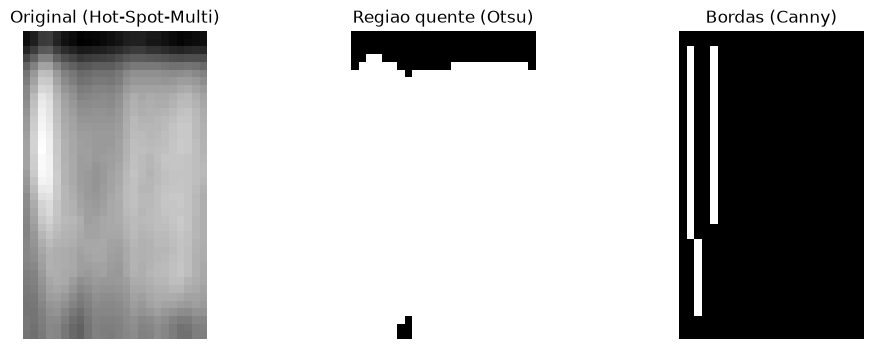

In [245]:
# Visualiza a regiao quente (Otsu) que alimenta as features
amostra_feat = df[df["anomaly_class"] == "Hot-Spot-Multi"].sample(1).iloc[0]
img_feat = cv2.imread(str(DATA_DIR / amostra_feat["image_filepath"]), cv2.IMREAD_GRAYSCALE)
otsu_t, _ = cv2.threshold(img_feat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, hot_vis = cv2.threshold(img_feat, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
edges_vis = cv2.Canny(img_feat, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, tt in zip(axes, [img_feat, hot_vis, edges_vis],
                      [f"Original ({amostra_feat['anomaly_class']})", "Regiao quente (Otsu)", "Bordas (Canny)"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(tt)
    ax.axis("off")
plt.show()

## 6. Matriz de features de todo o dataset

Extrai as features das 20.000 imagens (rápido, CPU). `X` = features, `y` = classe.

In [246]:
registros, y = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros.append(extrair_features(img))
    y.append(row["anomaly_class"])

X = np.array([[r[k] for k in FEAT_NAMES] for r in registros])
y = np.array(y)
print("X:", X.shape, "| y:", y.shape)

100%|██████████| 20000/20000 [00:10<00:00, 1960.73it/s]


X: (20000, 25) | y: (20000,)


## 7. Baseline: regra manual

Regra `if/else` na mão, para comparar com o classificador treinado. A ordem
dos testes segue o princípio **do mais extremo para o mais genérico**: a primeira
condição que casa decide, então casos abrangentes (catch-all) ficam por último.
Lógica por *quanto do módulo está quente*: nada → tudo quente → banda → pontos.

In [247]:
def classificar_regra(f):
    # 1. Nada quente -> modulo nominal (maioria, curto-circuito no topo)
    if f["max_int"] < 185 and f["hot_fraction"] < 0.12:
        return "No-Anomaly"
    # 2. Calor muito espalhado (mais extremo): modulo quase todo quente
    if f["hot_fraction"] >= 0.28 or f["largest_area"] >= 260:
        return "Hot-Spot-Multi" if f["num_blobs"] >= 2 else "Offline-Module"
    # 3. Mancha unica grande -> modulo desligado (aquecido por inteiro)
    if f["largest_area"] >= 190:
        return "Offline-Module"
    # 4. Banda quente (diodo de bypass aquece 1/3 ~ 2/3 do modulo)
    if f["row_cov"] >= 0.5:
        return "Diode-Multi"
    if f["row_cov"] >= 0.4 and f["largest_area"] >= 110:
        return "Diode"
    # 5. Pontos quentes localizados
    if f["num_blobs"] >= 2:
        return "Cell-Multi"
    return "Cell"


y_regra = [classificar_regra(r) for r in registros]
print(f"Baseline regra manual — acuracia: {accuracy_score(y, y_regra) * 100:.1f}% | "
      f"F1 macro: {f1_score(y, y_regra, average='macro') * 100:.1f}%")

Baseline regra manual — acuracia: 32.3% | F1 macro: 10.0%


## 8. Classificador treinado: RandomForest

Treina sobre as features. `class_weight='balanced'` compensa o desbalanceamento.
Split estratificado 70/30.

In [248]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

print(f"RandomForest — acuracia: {accuracy_score(y_te, pred) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred, average='macro') * 100:.1f}%\n")
print("--- Relatorio por classe ---")
print(classification_report(y_te, pred, zero_division=0))

RandomForest — acuracia: 61.9% | F1 macro: 41.9%

--- Relatorio por classe ---
                precision    recall  f1-score   support

          Cell       0.46      0.45      0.46       563
    Cell-Multi       0.36      0.25      0.29       386
      Cracking       0.59      0.73      0.65       282
         Diode       0.54      0.70      0.61       450
   Diode-Multi       0.39      0.21      0.28        52
      Hot-Spot       0.26      0.13      0.18        75
Hot-Spot-Multi       0.28      0.38      0.32        74
    No-Anomaly       0.82      0.77      0.79      3000
Offline-Module       0.29      0.46      0.36       248
     Shadowing       0.40      0.48      0.44       317
       Soiling       0.26      0.16      0.20        61
    Vegetation       0.46      0.46      0.46       492

      accuracy                           0.62      6000
     macro avg       0.43      0.43      0.42      6000
  weighted avg       0.63      0.62      0.62      6000



## 9. Resultados: matriz de confusão, importância das features e amostras previstas

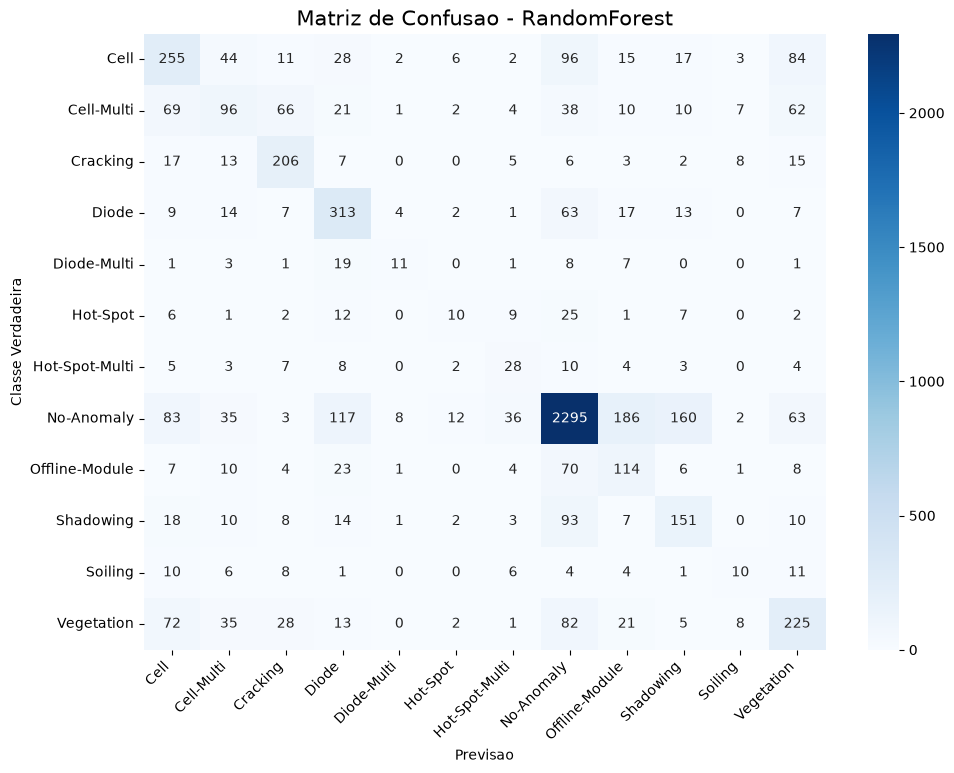

In [249]:
classes = sorted(set(y))
matriz = confusion_matrix(y_te, pred, labels=classes)
plt.figure(figsize=(11, 8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusao - RandomForest", fontsize=15)
plt.ylabel("Classe Verdadeira")
plt.xlabel("Previsao")
plt.xticks(rotation=45, ha="right")
plt.show()

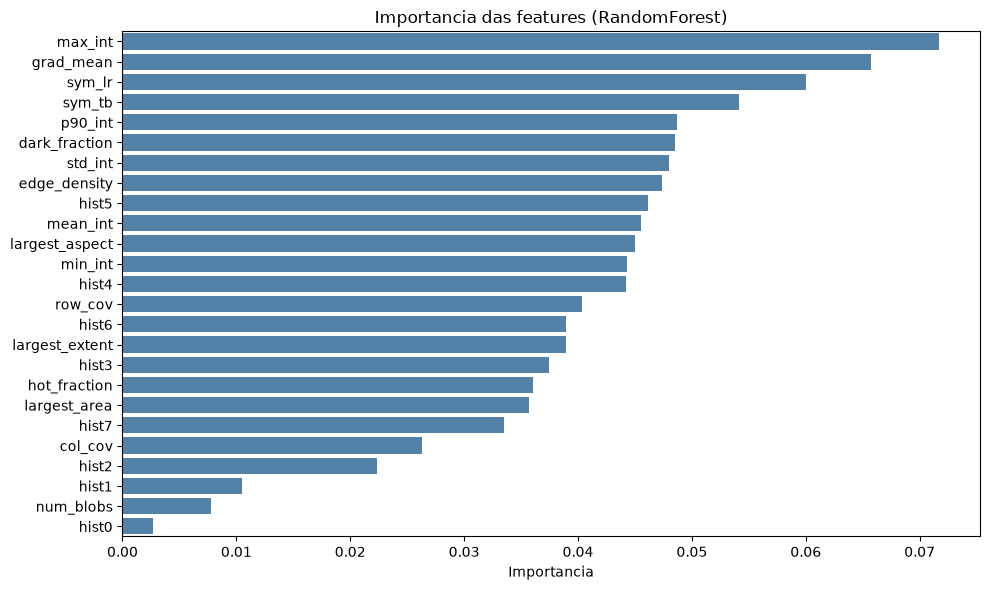

In [250]:
# Importancia das features
imp = sorted(zip(FEAT_NAMES, clf.feature_importances_), key=lambda x: x[1], reverse=True)
nomes, vals = zip(*imp)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(vals), y=list(nomes), color="steelblue")
plt.title("Importancia das features (RandomForest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

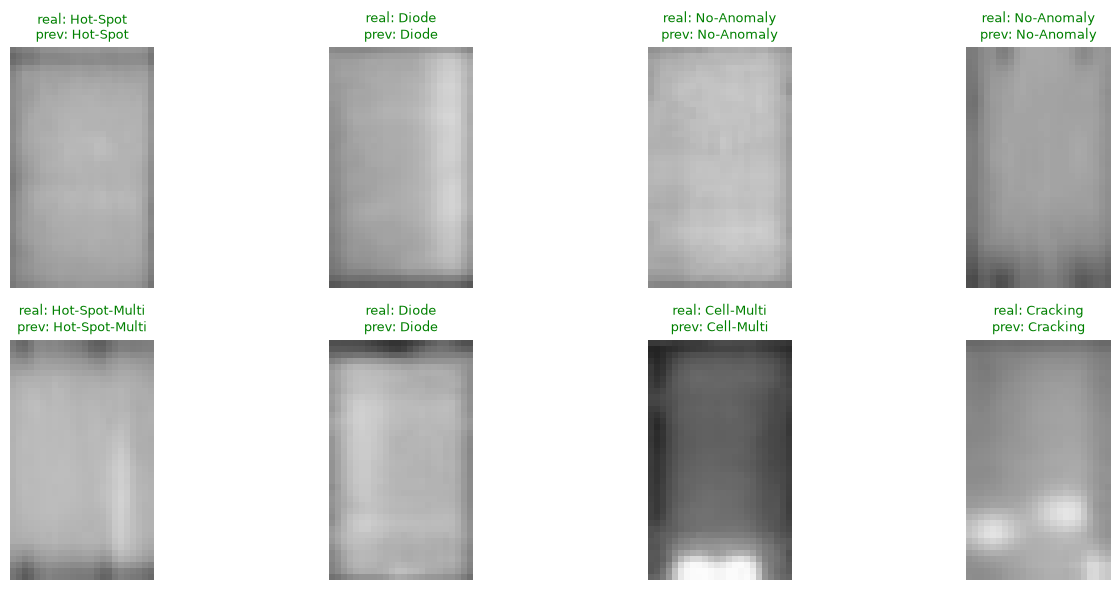

In [251]:
# Amostras aleatorias: classe real vs prevista pelo RandomForest (verde = acerto)
amostra_pred = df.sample(8, random_state=0)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (_, r) in zip(axes.ravel(), amostra_pred.iterrows()):
    img = cv2.imread(str(DATA_DIR / r["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    vec = np.array([[extrair_features(img)[k] for k in FEAT_NAMES]])
    pr = clf.predict(vec)[0]
    cor = "green" if pr == r["anomaly_class"] else "red"
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"real: {r['anomaly_class']}\nprev: {pr}", color=cor, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Comparação de classificadores: RandomForest vs Gradient Boosting vs SVM

Treinamos três classificadores sobre as **mesmas features** e o mesmo split, para
ver qual separa melhor:

- **RandomForest**: floresta de árvores por votação (bagging).
- **Gradient Boosting** (`HistGradientBoosting`): árvores em sequência, cada uma
  corrige o erro da anterior. Costuma ser forte em features tabulares.
- **SVM**: busca a fronteira de maior margem entre as classes. Precisa de features
  **normalizadas** (por isso vai num pipeline com `StandardScaler`).

Todos com balanceamento de classes (o dataset é desbalanceado).

In [252]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

modelos = {
    "RF": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "GB": HistGradientBoostingClassifier(random_state=42),
    "SVM": make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=42)),
}

resultados = []
preds = {}
for nome, modelo in modelos.items():
    if nome == "GB":  # balanceia via sample_weight
        modelo.fit(X_tr, y_tr, sample_weight=compute_sample_weight("balanced", y_tr))
    else:
        modelo.fit(X_tr, y_tr)
    p = modelo.predict(X_te)
    preds[nome] = p
    resultados.append({
        "modelo": nome,
        "acuracia": accuracy_score(y_te, p) * 100,
        "f1_macro": f1_score(y_te, p, average="macro") * 100,
    })

tabela = pd.DataFrame(resultados).set_index("modelo").round(1)
print(tabela)

        acuracia  f1_macro
modelo                    
RF          61.9      41.9
GB          54.3      38.5
SVM         42.0      32.9


## 11. Desempenho por classe de cada modelo

F1-score de cada classe em cada modelo. A coluna `melhor` aponta qual modelo vence
naquela classe. Assim dá para ver onde cada método é forte e onde é fraco.

In [253]:
f1_por_classe = {nome: f1_score(y_te, p, average=None, labels=classes) for nome, p in preds.items()}
tab_f1 = pd.DataFrame(f1_por_classe, index=classes).round(2)
tab_f1["melhor"] = tab_f1.idxmax(axis=1)
print(tab_f1)

                  RF    GB   SVM melhor
Cell            0.46  0.43  0.40     RF
Cell-Multi      0.29  0.32  0.22     GB
Cracking        0.65  0.62  0.63     RF
Diode           0.61  0.58  0.58     RF
Diode-Multi     0.28  0.23  0.11     RF
Hot-Spot        0.18  0.11  0.08     RF
Hot-Spot-Multi  0.32  0.28  0.14     RF
No-Anomaly      0.79  0.71  0.56     RF
Offline-Module  0.36  0.32  0.28     RF
Shadowing       0.44  0.37  0.37     RF
Soiling         0.20  0.21  0.19     GB
Vegetation      0.46  0.43  0.40     RF


## 12. Melhoria: features de grade 3x3 + LBP

Adicionamos dois grupos de features ao RandomForest, mantendo as mesmas 12 classes
para medir o impacto direto:

- **Grade 3x3** (9 features): divide a imagem em 9 células e mede a intensidade média
  de cada uma. Informa *onde* está o calor — útil para o Diode (aquece o terço inferior).
- **LBP** (Local Binary Patterns, 10 features): descritor de textura local. Ajuda em
  anomalias de superfície como Soiling.

In [254]:
from skimage.feature import local_binary_pattern


def extrair_features_extra(img):
    img = img.astype(np.uint8)
    h, w = img.shape
    hs, ws = h // 3, w // 3
    extra = {}
    # Grade 3x3: intensidade media por celula (localizacao do calor)
    for i in range(3):
        for j in range(3):
            y0, y1 = i * hs, (h if i == 2 else (i + 1) * hs)
            x0, x1 = j * ws, (w if j == 2 else (j + 1) * ws)
            extra[f"grid_{i}{j}"] = float(img[y0:y1, x0:x1].mean())
    # LBP uniforme (textura): histograma de 10 bins
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    for k, v in enumerate(hist):
        extra[f"lbp_{k}"] = float(v)
    return extra


def extrair_features_v2(img):
    return {**extrair_features(img), **extrair_features_extra(img)}


FEAT_NAMES_V2 = list(extrair_features_v2(img_original).keys())
print(f"{len(FEAT_NAMES_V2)} features agora (eram {len(FEAT_NAMES)})")

44 features agora (eram 25)


In [255]:
# Re-extrai features (base + grade + LBP) de todo o dataset
registros_v2, y2 = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros_v2.append(extrair_features_v2(img))
    y2.append(row["anomaly_class"])

X2 = np.array([[r[k] for k in FEAT_NAMES_V2] for r in registros_v2])
y2 = np.array(y2)

100%|██████████| 20000/20000 [00:19<00:00, 1051.80it/s]


In [256]:
# Re-treina o RandomForest com as novas features e compara com o baseline
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)
clf_v2 = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf_v2.fit(X2_tr, y2_tr)
pred_v2 = clf_v2.predict(X2_te)

print(f"RF base ({len(FEAT_NAMES)} features)    — acuracia: {accuracy_score(y_te, pred) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred, average='macro') * 100:.1f}%")
print(f"RF +grade+LBP ({len(FEAT_NAMES_V2)} feat) — acuracia: {accuracy_score(y2_te, pred_v2) * 100:.1f}% | "
      f"F1 macro: {f1_score(y2_te, pred_v2, average='macro') * 100:.1f}%")

RF base (25 features)    — acuracia: 61.9% | F1 macro: 41.9%
RF +grade+LBP (44 feat) — acuracia: 65.1% | F1 macro: 43.3%


## 13. Impacto por classe (F1: base vs +grade+LBP)

Mostra em quais classes as novas features ajudaram (delta positivo) ou atrapalharam.

In [257]:
f1_base = f1_score(y_te, pred, average=None, labels=classes)
f1_v2 = f1_score(y2_te, pred_v2, average=None, labels=classes)
tab_delta = pd.DataFrame({"F1_base": f1_base, "F1_v2": f1_v2}, index=classes).round(2)
tab_delta["delta"] = (tab_delta["F1_v2"] - tab_delta["F1_base"]).round(2)
print(tab_delta.sort_values("delta", ascending=False))

                F1_base  F1_v2  delta
Soiling            0.20   0.28   0.08
Shadowing          0.44   0.49   0.05
Vegetation         0.46   0.51   0.05
Offline-Module     0.36   0.41   0.05
No-Anomaly         0.79   0.82   0.03
Diode              0.61   0.63   0.02
Cracking           0.65   0.66   0.01
Cell-Multi         0.29   0.29   0.00
Cell               0.46   0.46   0.00
Hot-Spot-Multi     0.32   0.32   0.00
Hot-Spot           0.18   0.16  -0.02
Diode-Multi        0.28   0.16  -0.12


## 14. Agrupar Diode + Diode-Multi

`Diode` (aquece ~1/3 do módulo) e `Diode-Multi` (~2/3) são o mesmo defeito em graus
diferentes, e o modelo os confunde muito. Juntamos os dois numa classe `Diode` e
medimos o impacto. Usa as features v2 (grade + LBP). Vira um problema de **11 classes**.

In [258]:
# Remapeia os rotulos: Diode-Multi -> Diode
y_grp = np.where(y2 == "Diode-Multi", "Diode", y2)
classes_grp = sorted(set(y_grp))

Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(X2, y_grp, test_size=0.3, random_state=42, stratify=y_grp)
clf_grp = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf_grp.fit(Xg_tr, yg_tr)
pred_grp = clf_grp.predict(Xg_te)

print(f"v2 (12 classes)           — acuracia: {accuracy_score(y2_te, pred_v2) * 100:.1f}% | "
      f"F1 macro: {f1_score(y2_te, pred_v2, average='macro') * 100:.1f}%")
print(f"v2 + Diode agrupado (11)  — acuracia: {accuracy_score(yg_te, pred_grp) * 100:.1f}% | "
      f"F1 macro: {f1_score(yg_te, pred_grp, average='macro') * 100:.1f}%")

v2 (12 classes)           — acuracia: 65.1% | F1 macro: 43.3%
v2 + Diode agrupado (11)  — acuracia: 66.7% | F1 macro: 46.7%


In [259]:
# F1 por classe nos 3 estagios: base -> v2 -> agrupado (delta = impacto real)
f1_grp = f1_score(yg_te, pred_grp, average=None, labels=classes_grp)
s_base = pd.Series(f1_base, index=classes)
s_v2 = pd.Series(f1_v2, index=classes)
s_grp = pd.Series(f1_grp, index=classes_grp)

tab_total = pd.DataFrame({
    "F1_base": s_base.reindex(classes_grp),
    "F1_v2": s_v2.reindex(classes_grp),
    "F1_grp": s_grp,
})
tab_total["d_vs_v2"] = (tab_total["F1_grp"] - tab_total["F1_v2"]).round(2)
tab_total["d_vs_base"] = (tab_total["F1_grp"] - tab_total["F1_base"]).round(2)
print(tab_total.round(2).sort_values("d_vs_base", ascending=False))
print("\nNota: linha Diode no base/v2 usa so o Diode original (Diode-Multi estava")
print("separado com F1 0.28/0.16); na fusao os dois viram uma classe so.")

                F1_base  F1_v2  F1_grp  d_vs_v2  d_vs_base
Soiling            0.20   0.28    0.27    -0.00       0.07
Vegetation         0.46   0.51    0.52     0.01       0.07
Diode              0.61   0.63    0.67     0.03       0.06
Offline-Module     0.36   0.41    0.42     0.02       0.06
Shadowing          0.44   0.49    0.49    -0.00       0.06
No-Anomaly         0.79   0.82    0.83     0.01       0.04
Hot-Spot-Multi     0.32   0.32    0.36     0.04       0.04
Cell-Multi         0.29   0.29    0.33     0.03       0.03
Cracking           0.65   0.66    0.68     0.01       0.03
Cell               0.46   0.46    0.46     0.01       0.00
Hot-Spot           0.18   0.16    0.11    -0.05      -0.07

Nota: linha Diode no base/v2 usa so o Diode original (Diode-Multi estava
separado com F1 0.28/0.16); na fusao os dois viram uma classe so.


## 15. Agrupar também Hot-Spot + Hot-Spot-Multi

Mesma lógica do Diode: `Hot-Spot` e `Hot-Spot-Multi` são o mesmo defeito (ponto
quente em filme fino) em grau diferente, e o modelo os confunde. Agrupamos os dois,
em cima do agrupamento do Diode → problema de **10 classes**. Mede o impacto acumulado.

In [260]:
# Remapeia: Diode-Multi -> Diode (ja feito) e agora Hot-Spot-Multi -> Hot-Spot
y_grp2 = np.where(y_grp == "Hot-Spot-Multi", "Hot-Spot", y_grp)
classes_grp2 = sorted(set(y_grp2))

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X2, y_grp2, test_size=0.3, random_state=42, stratify=y_grp2)
clf_grp2 = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf_grp2.fit(Xh_tr, yh_tr)
pred_grp2 = clf_grp2.predict(Xh_te)

print(f"v2 (12 classes)                 — acuracia: {accuracy_score(y2_te, pred_v2) * 100:.1f}% | "
      f"F1 macro: {f1_score(y2_te, pred_v2, average='macro') * 100:.1f}%")
print(f"+ Diode agrupado (11 classes)   — acuracia: {accuracy_score(yg_te, pred_grp) * 100:.1f}% | "
      f"F1 macro: {f1_score(yg_te, pred_grp, average='macro') * 100:.1f}%")
print(f"+ Hot-Spot agrupado (10 classes)— acuracia: {accuracy_score(yh_te, pred_grp2) * 100:.1f}% | "
      f"F1 macro: {f1_score(yh_te, pred_grp2, average='macro') * 100:.1f}%")

v2 (12 classes)                 — acuracia: 65.1% | F1 macro: 43.3%
+ Diode agrupado (11 classes)   — acuracia: 66.7% | F1 macro: 46.7%
+ Hot-Spot agrupado (10 classes)— acuracia: 67.3% | F1 macro: 50.5%


In [261]:
# F1 por classe no cenario de 10 classes
f1_grp2 = f1_score(yh_te, pred_grp2, average=None, labels=classes_grp2)
tab_grp2 = pd.DataFrame({"F1": f1_grp2}, index=classes_grp2).round(2)
print(tab_grp2.sort_values("F1", ascending=False))
hs_antes = f1_score(yg_te, pred_grp, average=None, labels=classes_grp)
hs_idx = classes_grp.index("Hot-Spot") if "Hot-Spot" in classes_grp else None
print(f"\nHot-Spot antes da fusao  -> Hot-Spot: {hs_antes[hs_idx]:.2f}, "
      f"Hot-Spot-Multi: separado")
print(f"Hot-Spot depois da fusao -> {tab_grp2.loc['Hot-Spot', 'F1']:.2f}")

                  F1
No-Anomaly      0.83
Cracking        0.68
Diode           0.66
Shadowing       0.52
Vegetation      0.52
Cell            0.46
Offline-Module  0.44
Hot-Spot        0.35
Cell-Multi      0.32
Soiling         0.26

Hot-Spot antes da fusao  -> Hot-Spot: 0.11, Hot-Spot-Multi: separado
Hot-Spot depois da fusao -> 0.35
